# NB06 — Evaluación de las 6 configuraciones

## Propósito

Comparar las 6 configuraciones con las herramientas estadísticas adecuadas. Producir las tablas y figuras que irán a la memoria.

## ¿Qué calculamos?

### Para cada configuración (3 métricas + 2 de calibración)
Sobre OOF training (4.000 estudios o 8.000 mamas) y sobre test (1.000 estudios o 2.000 mamas):

- **AUC** con **IC 95% bootstrap** (1.000 remuestreos). Es la métrica principal de discriminación.
- **Brier score**: error cuadrático medio entre probabilidades predichas y etiquetas. Mide calibración + resolución. Mejor cuanto menor.
- **ECE (Expected Calibration Error)**: diferencia promedio entre confianza y precisión real, agrupando en deciles. Mide calibración pura. Mejor cuanto menor.

### Comparaciones pareadas — solo dentro de la misma granularidad

El **test pareado de DeLong** compara dos AUCs computados sobre **las mismas muestras**, teniendo en cuenta su correlación. Se aplica entre configuraciones que predicen sobre el mismo conjunto:

- **Dentro de nivel estudio** (4 configuraciones predicen sobre los mismos 4.000/1.000 estudios):
  - E_A_mlp vs E_B_mlp → ¿aporta la asimetría con MLP?
  - E_A_gbm vs E_B_gbm → ¿aporta la asimetría con GBM?
  - E_A_mlp vs E_A_gbm → ¿qué cabeza funciona mejor sobre Punto A?
  - E_B_mlp vs E_B_gbm → ¿qué cabeza funciona mejor sobre Punto B?

- **Dentro de nivel mama** (2 configuraciones predicen sobre las mismas 8.000/2.000 mamas):
  - M_A_mlp vs M_A_gbm → ¿qué cabeza funciona mejor a nivel mama?

### Comparaciones cruzadas (estudio ↔ mama)

**NO usamos DeLong** porque son muestras distintas. Reportamos AUCs absolutos con IC y se discuten cualitativamente.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from scipy import stats

# Raíz del proyecto: por defecto, la carpeta padre de notebooks/.
# Sobrescribible con la variable de entorno TFM_PROJECT_ROOT.
BASE      = os.environ.get('TFM_PROJECT_ROOT',
                           os.path.abspath(os.path.join(os.getcwd(), '..')))
OUTPUTS      = os.path.join(BASE, 'outputs')
FEATURES_DIR = os.path.join(OUTPUTS, 'Features')
PRED_DIR     = os.path.join(OUTPUTS, 'Predicciones')
PLOTS_DIR    = os.path.join(OUTPUTS, 'Plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

SEED = 42

## 1. Cargar predicciones y reconstruir etiquetas

Las predicciones OOF y test fueron guardadas por NB05. Las etiquetas las leemos del metadata. Para nivel mama, replicamos lo que hicimos en NB05: concatenar L y R.

In [2]:
meta = pd.read_csv(os.path.join(FEATURES_DIR, 'metadata.csv'))

# Nivel estudio
is_train_E = (meta['split'] == 'training').values
is_test_E  = (meta['split'] == 'test').values
y_E_train  = meta.loc[is_train_E, 'y_estudio'].values
y_E_test   = meta.loc[is_test_E,  'y_estudio'].values

# Nivel mama: concatenamos L y R (mismo orden que en NB05)
split_M  = np.concatenate([meta['split'].values, meta['split'].values])
y_M_all  = np.concatenate([meta['y_L'].values, meta['y_R'].values]).astype(int)
is_train_M = (split_M == 'training')
is_test_M  = (split_M == 'test')
y_M_train = y_M_all[is_train_M]
y_M_test  = y_M_all[is_test_M]

# Cargar predicciones de las 6 configuraciones
configs_E = ['E_A_mlp', 'E_A_gbm', 'E_B_mlp', 'E_B_gbm']
configs_M = ['M_A_mlp', 'M_A_gbm']
preds = {}
for c in configs_E + configs_M:
    preds[f'{c}_oof']  = np.load(os.path.join(PRED_DIR, f'{c}_oof.npy'))
    preds[f'{c}_test'] = np.load(os.path.join(PRED_DIR, f'{c}_test.npy'))

print(f'Nivel estudio: train n={is_train_E.sum()}  pos={int(y_E_train.sum())}  ({100*y_E_train.mean():.2f}%)')
print(f'               test  n={is_test_E.sum()}   pos={int(y_E_test.sum())}   ({100*y_E_test.mean():.2f}%)')
print(f'Nivel mama:    train n={is_train_M.sum()}  pos={int(y_M_train.sum())}  ({100*y_M_train.mean():.2f}%)')
print(f'               test  n={is_test_M.sum()}   pos={int(y_M_test.sum())}   ({100*y_M_test.mean():.2f}%)')

Nivel estudio: train n=3999  pos=385  (9.63%)
               test  n=1000   pos=96   (9.60%)
Nivel mama:    train n=7998  pos=395  (4.94%)
               test  n=2000   pos=99   (4.95%)


## 2. AUC + IC 95% bootstrap + Brier + ECE

**Bootstrap del AUC:** remuestrear con reemplazo n=1.000 veces sobre las muestras del conjunto evaluado, recomputando el AUC en cada réplica, y tomar los percentiles 2,5% y 97,5% como límites del IC. Es un método no paramétrico, no asume normalidad, y captura la incertidumbre real dada la muestra finita.

**Brier score:** `mean((p − y)²)`. Igual al MSE entre probabilidad y etiqueta. Penaliza tanto las probabilidades "muy seguras" cuando se equivocan como las "muy inseguras" cuando aciertan. Valor mínimo 0, valor de un clasificador trivial que predice la prevalencia ≈ 0,09 con prevalencia 10%.

**ECE (Expected Calibration Error):** agrupa las predicciones en deciles, y para cada decil compara `mean(y)` (precisión real) con `mean(p)` (confianza). El promedio ponderado de esas diferencias es el ECE. Un clasificador perfectamente calibrado tendría ECE=0.

In [3]:
def auc_ci_bootstrap(y_true, y_score, n_boot=1000, seed=42):
    """Devuelve (AUC, IC95% inferior, IC95% superior) mediante bootstrap."""
    rng = np.random.RandomState(seed)
    n = len(y_true)
    aucs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(set(y_true[idx])) < 2:
            continue  # remuestreo degenerado
        aucs.append(roc_auc_score(y_true[idx], y_score[idx]))
    aucs = np.array(aucs)
    return (float(roc_auc_score(y_true, y_score)),
            float(np.percentile(aucs, 2.5)),
            float(np.percentile(aucs, 97.5)))

def ece(y_true, y_score, n_bins=10):
    """Expected Calibration Error agrupando predicciones en n_bins (deciles por defecto)."""
    bins = np.linspace(0, 1, n_bins+1)
    e = 0.0
    for i in range(n_bins):
        mask = (y_score >= bins[i]) & (y_score < bins[i+1])
        if mask.sum() == 0: continue
        acc  = y_true[mask].mean()
        conf = y_score[mask].mean()
        e += (mask.sum() / len(y_true)) * abs(acc - conf)
    return float(e)

rows = []
for c in configs_E:
    for split, y_s, p in [('OOF training', y_E_train, preds[f'{c}_oof']),
                          ('test hold-out', y_E_test,  preds[f'{c}_test'])]:
        auc, lo, hi = auc_ci_bootstrap(y_s, p)
        brier = brier_score_loss(y_s, p)
        ece_v = ece(y_s, p)
        rows.append({'config': c, 'level': 'estudio', 'split': split,
                     'n': len(y_s), 'pos': int(y_s.sum()),
                     'auc': auc, 'ic_lo': lo, 'ic_hi': hi,
                     'brier': brier, 'ece': ece_v})

for c in configs_M:
    for split, y_s, p in [('OOF training', y_M_train, preds[f'{c}_oof']),
                          ('test hold-out', y_M_test,  preds[f'{c}_test'])]:
        auc, lo, hi = auc_ci_bootstrap(y_s, p)
        brier = brier_score_loss(y_s, p)
        ece_v = ece(y_s, p)
        rows.append({'config': c, 'level': 'mama', 'split': split,
                     'n': len(y_s), 'pos': int(y_s.sum()),
                     'auc': auc, 'ic_lo': lo, 'ic_hi': hi,
                     'brier': brier, 'ece': ece_v})

df_auc = pd.DataFrame(rows)
print(df_auc.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
df_auc.to_csv(os.path.join(PLOTS_DIR, 'auc_ci_bootstrap.csv'), index=False)

 config   level         split    n  pos    auc  ic_lo  ic_hi  brier    ece
E_A_mlp estudio  OOF training 3999  385 0.5964 0.5665 0.6280 0.2518 0.3308
E_A_mlp estudio test hold-out 1000   96 0.6211 0.5537 0.6855 0.1885 0.3245
E_A_gbm estudio  OOF training 3999  385 0.5787 0.5464 0.6109 0.0863 0.0287
E_A_gbm estudio test hold-out 1000   96 0.5953 0.5347 0.6596 0.0852 0.0231
E_B_mlp estudio  OOF training 3999  385 0.6247 0.5925 0.6576 0.2099 0.3481
E_B_mlp estudio test hold-out 1000   96 0.6065 0.5316 0.6778 0.1979 0.3422
E_B_gbm estudio  OOF training 3999  385 0.6213 0.5883 0.6518 0.0857 0.0238
E_B_gbm estudio test hold-out 1000   96 0.6312 0.5670 0.7040 0.0849 0.0212
M_A_mlp    mama  OOF training 7998  395 0.5568 0.5269 0.5836 0.3283 0.4261
M_A_mlp    mama test hold-out 2000   99 0.6830 0.6255 0.7405 0.2221 0.4218
M_A_gbm    mama  OOF training 7998  395 0.5874 0.5572 0.6173 0.0472 0.0224
M_A_gbm    mama test hold-out 2000   99 0.6032 0.5411 0.6658 0.0467 0.0344


## 3. Curvas ROC superpuestas

4 paneles: (estudio, mama) × (OOF training, test hold-out). En cada panel se superponen las curvas de las configuraciones aplicables, con el AUC entre paréntesis.

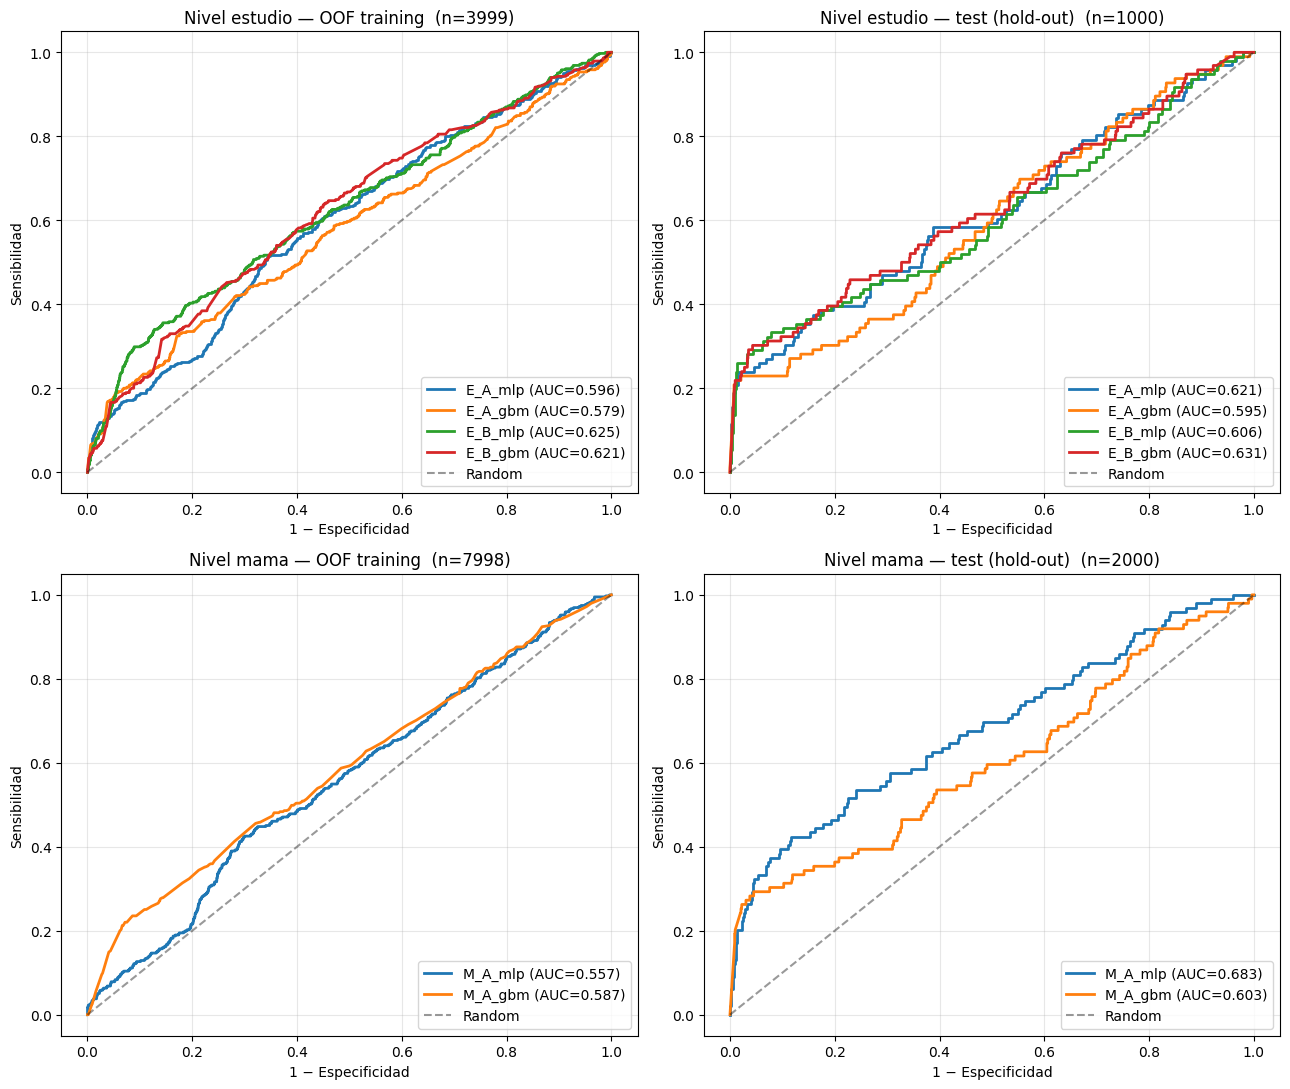

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

panels = [
    (axes[0,0], 'Nivel estudio — OOF training', y_E_train,
        [(c, preds[f'{c}_oof']) for c in configs_E]),
    (axes[0,1], 'Nivel estudio — test (hold-out)', y_E_test,
        [(c, preds[f'{c}_test']) for c in configs_E]),
    (axes[1,0], 'Nivel mama — OOF training', y_M_train,
        [(c, preds[f'{c}_oof']) for c in configs_M]),
    (axes[1,1], 'Nivel mama — test (hold-out)', y_M_test,
        [(c, preds[f'{c}_test']) for c in configs_M]),
]
for ax, title, y_s, items in panels:
    for name, score in items:
        fpr, tpr, _ = roc_curve(y_s, score)
        auc = roc_auc_score(y_s, score)
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
    ax.set_xlabel('1 − Especificidad'); ax.set_ylabel('Sensibilidad')
    ax.set_title(f'{title}  (n={len(y_s)})')
    ax.legend(loc='lower right'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'roc_comparacion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Test pareado de DeLong

Implementación rápida basada en Sun & Xu (2014). El test devuelve:

- **Δ AUC** = AUC_B − AUC_A.
- **z**: estadístico de la diferencia normalizado por su varianza estimada.
- **p-valor**: probabilidad de observar una diferencia tan grande (o mayor) bajo H₀ de que ambos AUCs son iguales.

Si **p < 0.05**, rechazamos H₀: hay evidencia de que un modelo es mejor que el otro sobre esas muestras.

In [5]:
def compute_midrank(x):
    """Mid-rank: rangos con tratamiento de ties por promedio."""
    J = np.argsort(x); Z = x[J]; N = len(x)
    T = np.zeros(N, dtype=np.float64); i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]: j += 1
        T[i:j] = 0.5*(i+j-1) + 1; i = j
    T2 = np.empty(N, dtype=np.float64); T2[J] = T
    return T2

def fast_delong(predictions, labels):
    """
    predictions: (k, n) — k modelos, n muestras.
    labels: (n,) binarias.
    Devuelve aucs (k,) y matriz de covarianza (k, k).
    """
    order = np.argsort(-labels)
    labels = labels[order]; predictions = predictions[:, order]
    m = int(labels.sum()); n = len(labels) - m
    pos = predictions[:, :m]; neg = predictions[:, m:]
    k = predictions.shape[0]
    tx = np.empty([k, m]); ty = np.empty([k, n]); tz = np.empty([k, m+n])
    for r in range(k):
        tx[r] = compute_midrank(pos[r])
        ty[r] = compute_midrank(neg[r])
        tz[r] = compute_midrank(predictions[r])
    aucs = tz[:, :m].sum(axis=1)/(m*n) - (m+1.0)/(2.0*n)
    v01 = (tz[:, :m] - tx)/n
    v10 = 1.0 - (tz[:, m:] - ty)/m
    sx = np.cov(v01); sy = np.cov(v10)
    if k == 1: sx = np.array([[sx]]); sy = np.array([[sy]])
    cov = sx/m + sy/n
    return aucs, cov

def delong_paired(scores_a, scores_b, labels):
    """Test pareado de DeLong: H₀: AUC_a == AUC_b sobre las mismas muestras."""
    aucs, cov = fast_delong(np.vstack([scores_a, scores_b]).astype(np.float64),
                            labels.astype(np.int32))
    a, b = aucs
    var_diff = cov[0,0] + cov[1,1] - 2*cov[0,1]
    z = (b - a) / np.sqrt(max(var_diff, 1e-12))
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return {'auc_a': float(a), 'auc_b': float(b),
            'delta': float(b-a), 'z': float(z), 'p_value': float(p)}

print('DeLong implementado.')

DeLong implementado.


## 5. Aplicar DeLong a nivel estudio

4 comparaciones × 2 splits = 8 tests.

In [6]:
delong_rows = []
comparaciones_E = [
    ('E_A_mlp', 'E_B_mlp'),   # ¿asimetría aporta con MLP?
    ('E_A_gbm', 'E_B_gbm'),   # ¿asimetría aporta con GBM?
    ('E_A_mlp', 'E_A_gbm'),   # ¿MLP o GBM sobre Punto A?
    ('E_B_mlp', 'E_B_gbm'),   # ¿MLP o GBM sobre Punto B?
]
for split_name, y_s, suffix in [('OOF training', y_E_train, 'oof'),
                                ('test hold-out', y_E_test,  'test')]:
    print(f'\n--- Nivel estudio, {split_name} (n={len(y_s)}) ---')
    print(f'{"comparación":<22} {"AUC_a":>8} {"AUC_b":>8} {"Δ":>9} {"z":>7} {"p-valor":>10} {"sig":>4}')
    for a, b in comparaciones_E:
        r = delong_paired(preds[f'{a}_{suffix}'], preds[f'{b}_{suffix}'], y_s)
        sig = '✓' if r['p_value'] < 0.05 else '—'
        print(f'{a:>10} vs {b:<8}  {r["auc_a"]:>8.4f} {r["auc_b"]:>8.4f} '
              f'{r["delta"]:>+9.4f} {r["z"]:>+7.3f} {r["p_value"]:>10.4f}   {sig}')
        r.update({'level': 'estudio', 'split': split_name, 'comparison': f'{a} vs {b}'})
        delong_rows.append(r)


--- Nivel estudio, OOF training (n=3999) ---
comparación               AUC_a    AUC_b         Δ       z    p-valor  sig
   E_A_mlp vs E_B_mlp     0.5964   0.6247   +0.0283  +1.383     0.1667   —
   E_A_gbm vs E_B_gbm     0.5787   0.6213   +0.0426  +2.238     0.0252   ✓
   E_A_mlp vs E_A_gbm     0.5964   0.5787   -0.0178  -0.877     0.3805   —
   E_B_mlp vs E_B_gbm     0.6247   0.6213   -0.0034  -0.188     0.8511   —

--- Nivel estudio, test hold-out (n=1000) ---
comparación               AUC_a    AUC_b         Δ       z    p-valor  sig
   E_A_mlp vs E_B_mlp     0.6211   0.6065   -0.0146  -0.515     0.6066   —
   E_A_gbm vs E_B_gbm     0.5953   0.6312   +0.0359  +1.171     0.2417   —
   E_A_mlp vs E_A_gbm     0.6211   0.5953   -0.0258  -0.969     0.3324   —
   E_B_mlp vs E_B_gbm     0.6065   0.6312   +0.0247  +0.709     0.4786   —


## 6. Aplicar DeLong a nivel mama

1 comparación × 2 splits = 2 tests.

In [7]:
comparaciones_M = [('M_A_mlp', 'M_A_gbm')]
for split_name, y_s, suffix in [('OOF training', y_M_train, 'oof'),
                                ('test hold-out', y_M_test,  'test')]:
    print(f'\n--- Nivel mama, {split_name} (n={len(y_s)}) ---')
    print(f'{"comparación":<22} {"AUC_a":>8} {"AUC_b":>8} {"Δ":>9} {"z":>7} {"p-valor":>10} {"sig":>4}')
    for a, b in comparaciones_M:
        r = delong_paired(preds[f'{a}_{suffix}'], preds[f'{b}_{suffix}'], y_s)
        sig = '✓' if r['p_value'] < 0.05 else '—'
        print(f'{a:>10} vs {b:<8}  {r["auc_a"]:>8.4f} {r["auc_b"]:>8.4f} '
              f'{r["delta"]:>+9.4f} {r["z"]:>+7.3f} {r["p_value"]:>10.4f}   {sig}')
        r.update({'level': 'mama', 'split': split_name, 'comparison': f'{a} vs {b}'})
        delong_rows.append(r)

df_delong = pd.DataFrame(delong_rows)
df_delong.to_csv(os.path.join(PLOTS_DIR, 'delong_pareado.csv'), index=False)
print(f'\nGuardado en {PLOTS_DIR}\\delong_pareado.csv')


--- Nivel mama, OOF training (n=7998) ---
comparación               AUC_a    AUC_b         Δ       z    p-valor  sig
   M_A_mlp vs M_A_gbm     0.5568   0.5874   +0.0306  +1.639     0.1012   —

--- Nivel mama, test hold-out (n=2000) ---
comparación               AUC_a    AUC_b         Δ       z    p-valor  sig
   M_A_mlp vs M_A_gbm     0.6830   0.6032   -0.0798  -2.339     0.0193   ✓

Guardado en C:\Users\victo\Documents\TFM\Proyecto\Outputs\Plots\delong_pareado.csv


## 7. Mejor configuración por nivel

La candidata para fusión con densidad (NB07) será la mejor por AUC test.

In [8]:
df_test = df_auc[df_auc.split == 'test hold-out'].copy()

best_E = df_test[df_test.level == 'estudio'].sort_values('auc', ascending=False).iloc[0]
best_M = df_test[df_test.level == 'mama'].sort_values('auc', ascending=False).iloc[0]

print('Mejor configuración por nivel (según AUC test):')
print(f'  Estudio: {best_E["config"]}   AUC = {best_E["auc"]:.4f}  IC95% [{best_E["ic_lo"]:.4f}, {best_E["ic_hi"]:.4f}]')
print(f'  Mama:    {best_M["config"]}   AUC = {best_M["auc"]:.4f}  IC95% [{best_M["ic_lo"]:.4f}, {best_M["ic_hi"]:.4f}]')

best_overall = df_test.sort_values('auc', ascending=False).iloc[0]
print(f'\nMejor global: {best_overall["config"]} ({best_overall["level"]})')

Mejor configuración por nivel (según AUC test):
  Estudio: E_B_gbm   AUC = 0.6312  IC95% [0.5670, 0.7040]
  Mama:    M_A_mlp   AUC = 0.6830  IC95% [0.6255, 0.7405]

Mejor global: M_A_mlp (mama)


## Lectura de resultados (para la memoria)

Tres preguntas y cómo contestarlas con la tabla:

1. **¿La asimetría aporta sobre el simple backbone?** Mirar E_B vs E_A para cada cabeza:
   - Si DeLong p<0.05 y delta>0 → la asimetría aporta de forma significativa.
   - Si no significativo pero delta consistente → tendencia pero no demostración fuerte.

2. **¿Qué cabeza es mejor?** Mirar MLP vs GBM en cada punto. Atender también a Brier y ECE:
   - GBM con AUC similar o mejor + calibración mucho mejor → GBM es elección "clínicamente segura".
   - MLP con AUC notablemente mejor pero calibración terrible → MLP solo si importa ranking, no probabilidades.

3. **¿Estudio o mama?** Mirar AUC test de la mejor de cada nivel. Recordar que los IC se solapan típicamente con n pequeños; reportar con prudencia.

## Siguiente paso

`07_fusion_densidad.ipynb` — sobre la mejor configuración, añadir la covariable de densidad mamaria (factor de riesgo conocido) y ver si mejora el AUC.